# The Spectral-Gauge Associative Memory Architecture
## A PyTorch Implementation of Sparse Geometric Signal Transport for Causal Language Modeling

**Author:** David Ledbetter

---

This notebook provides a complete, runnable PyTorch implementation of the Spectral-Gauge Associative Memory architecture — a novel neural network framework that replaces the flat Euclidean geometry of standard Transformers with computation over fiber bundles equipped with gauge connections and Finsler causal structure.

### Key Architectural Principles

1. **Fiber Bundles over Manifolds**: Tokens are sparse sections of a fiber bundle $E = \coprod_{q \in \mathcal{M}} \mathcal{F}_q$, not dense vectors in $\mathbb{R}^d$.

2. **Spectral Gauge-Covariant Transport**: Parallel transport and forward diffusion are unified in the frequency domain via:
$$\tilde{X}_q = X_p \odot \exp\left(-D\omega^2 - i\omega\int_\gamma A\right)$$

3. **Finsler Causal Structure**: Asymmetric geometry enforces autoregressive causality as a structural property — no masking needed.

4. **Langevin-Hopfield Energy Descent**: Token prediction collapses a continuous probability cloud into a sparse attractor via annealed stochastic dynamics on a Modern Hopfield energy landscape.

5. **Proximal Sparsity**: Soft-thresholding at each Langevin step enforces biological lateral inhibition, driving weak activations to exact zero.

### Correspondence to Standard Transformers

| Standard Transformer | This Architecture |
|---|---|
| Token embedding in $\mathbb{R}^d$ | Sparse section of fiber bundle |
| Causal attention mask | Finsler metric asymmetry |
| KV cache | Wilson line holonomy |
| FFN + residual | Spectral advection-diffusion transport |
| Softmax + sampling | Langevin energy descent + proximal sparsity |

In [73]:
# edit_time: 03/10/2026 22:13:54
# Changed: Added tqdm.notebook import for training progress bar.

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, NamedTuple
from dataclasses import dataclass
import math
from tqdm.notebook import tqdm

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


---
## 1. Configuration and Hyperparameters

We define a unified configuration object that parameterizes every component of the architecture. The dimensions are chosen to be tractable for demonstration while preserving the full mathematical structure.

In [74]:
# edit_time: 03/10/2026 22:10:28
# Changed: n_transport_layers 7->3, langevin_steps 10->5, beta_final 20->10,
#   sparsity_lambda 0.05->0.3, inhibition_gamma 0.05->0.1, learning_rate 1e-3->3e-4,
#   n_epochs 50->100, added dropout=0.1
# edit_time: 03/11/2026 00:32:13
# Changed: Reverted depth to working config (n_transport_layers 5->3, langevin_steps 7->5).
#   5 layers was too deep to optimize. Kept dropout=0.05, weight_decay=0.02 from round 2.
#   Key new change: GaugeConnection is now content-aware (see cell 7).

@dataclass
class ArchitectureConfig:
    """Complete configuration for the Spectral-Gauge Associative Memory Architecture."""

    # --- Fiber Bundle Geometry ---
    fiber_dim: int = 128            # Total dimension of each fiber F_q
    n_subbundles: int = 8           # K orthogonal subbundle channels (syntax, semantics, routing, etc.)
    manifold_dim: int = 64          # Dimension of base manifold coordinates q

    # --- Vocabulary & Embedding ---
    vocab_size: int = 256           # Token vocabulary size
    max_seq_len: int = 128          # Maximum sequence length (geodesic length)

    # --- Sparse Dictionary (Section 3) ---
    n_dictionary_atoms: int = 512   # N_global: size of overcomplete dictionary D
    k_wta: int = 64                 # k for k-Winner-Take-All gating

    # --- Spectral Transport (Section 2) ---
    diffusion_coeff: float = 0.01   # D: forward diffusion coefficient
    n_transport_layers: int = 3     # Number of sequential transport steps (depth)

    # --- Langevin Dynamics (Section 4) ---
    langevin_steps: int = 5         # Number of reverse diffusion steps
    langevin_lr: float = 0.1        # eta: Langevin step size
    beta_init: float = 1.0          # Initial inverse temperature
    beta_final: float = 10.0        # Final inverse temperature (annealing target)

    # --- Sparsity (Section 5) ---
    sparsity_lambda: float = 0.3    # lambda: soft-thresholding penalty
    inhibition_gamma: float = 0.1   # gamma: lateral inhibition strength

    # --- Training ---
    learning_rate: float = 5e-4
    dropout: float = 0.05
    batch_size: int = 32
    n_epochs: int = 150

    @property
    def subbundle_dim(self) -> int:
        """Dimension of each orthogonal subbundle F_q^(k)."""
        assert self.fiber_dim % self.n_subbundles == 0
        return self.fiber_dim // self.n_subbundles


config = ArchitectureConfig()
print(f"Fiber dim: {config.fiber_dim} = {config.n_subbundles} subbundles x {config.subbundle_dim} dims each")
print(f"Dictionary: {config.n_dictionary_atoms} atoms, k-WTA selects {config.k_wta}")
print(f"Langevin: {config.langevin_steps} steps, beta {config.beta_init} -> {config.beta_final}")

Fiber dim: 128 = 8 subbundles x 16 dims each
Dictionary: 512 atoms, k-WTA selects 64
Langevin: 5 steps, beta 1.0 -> 10.0


---
## 2. Topological Foundation: Sparse Fiber Bundle Representation

### Section 1 of the Architecture

The fiber bundle $E = \coprod_{q \in \mathcal{M}} \mathcal{F}_q$ is the total computational space. Each token is a **sparse section** — a vector in the local fiber $\mathcal{F}_q$ with most components exactly zero.

The fiber decomposes into $K$ orthogonal subbundles:
$$\mathcal{F}_q = \bigoplus_{k=1}^{K} \mathcal{F}_q^{(k)}$$

This partitioning prevents representational collapse by maintaining independent feature channels. We implement two key primitives:

- **`SparseTokenEmbedding`**: Maps discrete vocabulary tokens to sparse fiber sections via a learned embedding followed by top-k activation.
- **`soft_threshold`**: The proximal operator $\text{sign}(x) \odot \max(|x| - \lambda, 0)$ that enforces biological sparsity at each Langevin step.

In [75]:
def soft_threshold(x: torch.Tensor, lam: float) -> torch.Tensor:
    """Proximal operator for L1 sparsity (Section 5).

    Implements: sign(x) * max(|x| - lambda, 0)

    This is the mathematical equivalent of lateral cortical inhibition:
    weak activations are driven to exact zero while strong activations
    are preserved with a bias shift.
    """
    return torch.sign(x) * F.relu(torch.abs(x) - lam)


def k_wta(x: torch.Tensor, k: int) -> torch.Tensor:
    """k-Winner-Take-All activation (Section 3).

    Retains only the top-k values per sample, zeroing everything else.
    This is the gating function g(q) that selects which dictionary atoms
    are active at a given manifold coordinate.
    """
    topk_vals, topk_idx = torch.topk(x, k, dim=-1)
    out = torch.zeros_like(x)
    out.scatter_(-1, topk_idx, topk_vals)
    return out


class SparseTokenEmbedding(nn.Module):
    """Maps vocabulary tokens to sparse fiber sections.

    Each token is embedded into the full fiber space R^d, then sparsified
    per-subbundle to produce a section x_q = (S_q, a_q) with sparse support S
    and non-zero amplitudes a.

    The subbundle decomposition F_q = ⊕_k F_q^(k) is enforced by applying
    independent top-k sparsification within each subbundle channel.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = nn.Embedding(cfg.vocab_size, cfg.fiber_dim)
        # Number of non-zero activations per subbundle
        self.topk_per_subbundle = max(1, cfg.subbundle_dim // 4)

        # Learnable positional encoding on the manifold
        # These are the coordinates q on the base manifold M
        self.manifold_coords = nn.Embedding(cfg.max_seq_len, cfg.manifold_dim)

    def forward(self, token_ids: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            token_ids: (batch, seq_len) integer token IDs

        Returns:
            x_sparse: (batch, seq_len, fiber_dim) sparse fiber sections
            q_coords: (batch, seq_len, manifold_dim) manifold coordinates
        """
        B, T = token_ids.shape
        x_dense = self.embedding(token_ids)  # (B, T, fiber_dim)

        # Sparsify per-subbundle: enforce F_q = ⊕_k F_q^(k) independence
        chunks = x_dense.chunk(self.cfg.n_subbundles, dim=-1)
        sparse_chunks = []
        for chunk in chunks:
            # Within each subbundle, keep only top-k activations
            topk_vals, topk_idx = torch.topk(
                chunk.abs(), self.topk_per_subbundle, dim=-1
            )
            mask = torch.zeros_like(chunk)
            mask.scatter_(-1, topk_idx, 1.0)
            sparse_chunks.append(chunk * mask)

        x_sparse = torch.cat(sparse_chunks, dim=-1)

        # Manifold coordinates for each position
        positions = torch.arange(T, device=token_ids.device)
        q_coords = self.manifold_coords(positions).unsqueeze(0).expand(B, -1, -1)

        return x_sparse, q_coords


# --- Demonstrate sparse embedding ---
embed = SparseTokenEmbedding(config)
test_ids = torch.randint(0, config.vocab_size, (2, 8))
x_sparse, q_coords = embed(test_ids)

sparsity = (x_sparse == 0).float().mean().item()
print(f"Sparse embedding shape: {x_sparse.shape}")
print(f"Manifold coordinates shape: {q_coords.shape}")
print(f"Sparsity ratio: {sparsity:.1%}")
print(f"Active dims per token: {(x_sparse != 0).float().sum(-1).mean().item():.0f} / {config.fiber_dim}")

Sparse embedding shape: torch.Size([2, 8, 128])
Manifold coordinates shape: torch.Size([2, 8, 64])
Sparsity ratio: 75.0%
Active dims per token: 32 / 128


---
## 3. The Gauge Connection and Spectral Transport Operator

### v4: Two-Stage Parallel Transport (03/11/2026 01:43)

The transport operator is the computational core, replacing both self-attention and feed-forward layers. It operates on the **full sequence in parallel** via two stages:

**Stage 1 — Per-fiber gauge transport** (advection-diffusion within each token):
$$\tilde{X}_q = X_p \odot \exp\left(-D\omega^2 - i\omega\int_\gamma A\right)$$
FFT over `fiber_dim` applies the heat kernel (diffusion) and gauge holonomy (phase rotation) to each token independently. The Wilson line is the cumulative sum of per-position gauge phases along the sequence path.

**Stage 2 — Cross-position causal mixing** (the attention analogue):
FFT over the **sequence dimension** implements a causal convolution at $O(T \log T)$ complexity. Each fiber dimension has a learned temporal receptive field (via softmax over lag weights), allowing different feature channels to attend to different time scales. Zero-padding ensures linear (non-circular) convolution with strict causality.

### Finsler Causality

Causality is enforced by the causal convolution kernel: position $t$'s output depends only on positions $0..t$. The kernel weights are normalized via softmax with a recency bias, but the model can learn to attend far back when needed.

### Wilson Line Accumulation (CLM Section 3)

The holonomy $U_\gamma = \mathcal{P}\exp(i\int_{p_1}^{p_t} A)$ is the path-ordered exponential of the connection. In our discrete implementation, this is the sequential product of per-step gauge transformations — functionally equivalent to a KV cache, but encoding context as geometric phase rather than cached vectors.

In [76]:
# === ARCHITECTURE EVOLUTION LOG ===
# v1 (03/10/2026 22:10): GaugeConnection position-only, SpectralTransportOperator
#   applied FFT over fiber_dim per-token. Each position processed independently.
#   Result: no cross-position communication. Model could not learn sequences.
# v2 (03/11/2026 00:32): Tried content-aware GaugeConnection (fed token state x).
#   Result: training collapsed — too complex, feedback loop.
# v3 (03/11/2026 00:40): Reverted to position-only gauge. Added ContextGate for
#   sequential context blending. Result: 35% val accuracy, but sequential (RNN-like).
#   Fundamental flaw: token 5 cannot directly access token 1.
# v4 (03/11/2026 01:43): MAJOR RESTRUCTURE. FFT now over SEQUENCE dimension,
#   not fiber dimension. All positions processed in parallel. Cross-position
#   mixing via causal spectral convolution (O(T log T) attention analogue).
#   Two-stage transport: (1) per-fiber gauge rotation, (2) causal sequence mixing.
#   Wilson line computed via cumsum over pre-computed phases.
#   ContextGate removed — no longer needed.
# v4.1 (03/11/2026 01:58): Causal kernel overfitting fix. Replaced fully-learned
#   causal_logits (max_seq_len x fiber_dim = 16K params/block) with parametric
#   exponential decay (fiber_dim = 128 params/block). Each fiber dim learns one
#   decay rate. Reduces kernel params by 128x while preserving expressiveness.
# v4.2 (03/11/2026 02:07): Content-dependent gating (Hyena-style). The causal
#   convolution provides positional mixing (content-independent). A learned gate
#   sigmoid(Wx) then selects PER-TOKEN how much mixed vs original signal to keep.
#   This restores the content-dependence that made ContextGate (v3) work at 35%,
#   but in a fully parallel architecture. Parallel + content-dependent = best of both.

class GaugeConnection(nn.Module):
    """Learnable gauge field A that defines parallel transport between fibers.

    Computes per-position phase vectors from manifold coordinates.
    Supports batched operation over all sequence positions simultaneously.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.connection_net = nn.Sequential(
            nn.Linear(2 * cfg.manifold_dim, cfg.fiber_dim),
            nn.SiLU(),
            nn.Linear(cfg.fiber_dim, cfg.fiber_dim),
            nn.Tanh(),
        )
        self.log_diffusion = nn.Parameter(
            torch.full((cfg.fiber_dim,), math.log(cfg.diffusion_coeff))
        )

    def forward(
        self, q_source: torch.Tensor, q_target: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Batch-compute gauge connection for arbitrary number of position pairs.

        Args:
            q_source: (*, manifold_dim) source coordinates
            q_target: (*, manifold_dim) target coordinates

        Returns:
            phase: (*, fiber_dim) the holonomy phase
            diffusion_kernel: (*, fiber_dim) the heat kernel
        """
        q_pair = torch.cat([q_source, q_target], dim=-1)
        phase = self.connection_net(q_pair) * math.pi

        d = self.cfg.fiber_dim
        omega = torch.fft.fftfreq(d, device=q_source.device)
        omega = omega * 2 * math.pi

        D = self.log_diffusion.exp()
        diffusion_kernel = torch.exp(-D * omega ** 2)
        # Broadcast to match batch dims
        diffusion_kernel = diffusion_kernel.expand_as(phase)

        return phase, diffusion_kernel


class SpectralTransportOperator(nn.Module):
    """Parallel spectral gauge-covariant transport over the full sequence.

    === v4 ARCHITECTURE (03/11/2026 01:43), v4.1 KERNEL FIX (03/11/2026 01:58) ===

    Two-stage operation replacing the old per-token FFT:

    Stage 1 — Per-fiber gauge transport:
        FFT over fiber_dim applies gauge rotation (holonomy) and diffusion
        within each token's fiber space. This is the advection-diffusion
        equation from the architecture: X~ = X * exp(-Dw^2 - iw * integral(A))

    Stage 2 — Cross-position causal mixing (THE ATTENTION ANALOGUE):
        Causal convolution over the SEQUENCE dimension via FFT.
        Each fiber dimension has a learned DECAY RATE controlling its
        temporal receptive field. This is what allows token 5 to directly
        access token 1. Complexity: O(T log T) vs O(T^2) for attention.

    v4.2 key insight: position-dependent mixing alone (causal conv) is not enough.
    The ContextGate (v3) worked because it was CONTENT-dependent — different tokens
    got different blend ratios. The causal conv applies the same weights to all tokens.

    Solution (Hyena-style): after causal convolution, apply a content-dependent gate:
        gate = sigmoid(W @ x)
        output = gate * mixed + (1 - gate) * original
    This gives the model per-token control over how much cross-position information
    to incorporate. Still fully parallel, still O(T log T).
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.gauge = GaugeConnection(cfg)

        # Per-fiber decay rate for causal mixing kernel.
        # Each fiber dim learns ONE scalar: its temporal receptive field width.
        # Initialized so some dims look nearby, others look far back.
        self.log_decay = nn.Parameter(
            torch.linspace(-1.0, 2.0, cfg.fiber_dim)
        )

        # Content-dependent gate (Hyena-style):
        # Per-token, per-fiber gating of how much causal-mixed signal to use.
        # This restores the content-dependence that made v3 (ContextGate) effective.
        self.content_gate = nn.Sequential(
            nn.Linear(cfg.fiber_dim, cfg.fiber_dim),
            nn.Sigmoid(),
        )

        self.norm = nn.LayerNorm(cfg.fiber_dim)

    def forward(
        self, x_seq: torch.Tensor, q_coords: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Transport all positions in parallel.

        Args:
            x_seq: (B, T, fiber_dim) full sequence of token states
            q_coords: (B, T, manifold_dim) manifold coordinates

        Returns:
            x_out: (B, T, fiber_dim) transported sequence (all positions)
            wilson: (B, T, fiber_dim) Wilson line phases
        """
        B, T, D = x_seq.shape

        # --- Stage 1: Per-fiber gauge transport (advection-diffusion) ---
        # Compute phases for all consecutive position pairs in parallel
        q_next = torch.roll(q_coords, -1, dims=1)
        q_next[:, -1] = q_coords[:, -1]  # Last position: self-loop

        # Flatten (B,T) -> (B*T) for batched gauge computation
        phase_all, diff_all = self.gauge(
            q_coords.reshape(-1, q_coords.size(-1)),
            q_next.reshape(-1, q_next.size(-1)),
        )
        phase_all = phase_all.reshape(B, T, D)
        diff_all = diff_all.reshape(B, T, D)

        # Wilson line: cumulative phase along the sequence path
        wilson = torch.cumsum(phase_all, dim=1)  # (B, T, D)

        # Per-fiber spectral transport: FFT over fiber_dim
        omega = torch.fft.fftfreq(D, device=x_seq.device) * 2 * math.pi
        gauge_rot = torch.exp(-1j * omega * wilson)

        X_fiber = torch.fft.fft(x_seq, dim=-1)
        X_transported = X_fiber * diff_all.to(X_fiber.dtype) * gauge_rot
        x_gauge = torch.fft.ifft(X_transported, dim=-1).real  # (B, T, D)

        # --- Stage 2: Cross-position causal mixing (attention analogue) ---
        # Parametric exponential decay kernel: kernel[lag, d] = exp(-alpha_d * lag)
        # Each fiber dim has its own decay rate (learned temporal receptive field)
        decay = F.softplus(self.log_decay)  # (D,) — positive decay rates
        lags = torch.arange(T, device=x_seq.device).float()  # (T,)
        causal_kernel = torch.exp(-decay.unsqueeze(0) * lags.unsqueeze(-1))  # (T, D)
        causal_kernel = causal_kernel / (causal_kernel.sum(dim=0, keepdim=True) + 1e-8)

        # Causal convolution via FFT (zero-pad for linear, non-circular conv)
        x_padded = F.pad(x_gauge, (0, 0, 0, T))       # (B, 2T, D)
        k_padded = F.pad(causal_kernel, (0, 0, 0, T))  # (2T, D)

        X_seq = torch.fft.fft(x_padded, dim=1)           # (B, 2T, D)
        K_seq = torch.fft.fft(k_padded, dim=0).unsqueeze(0)  # (1, 2T, D)

        Y_seq = X_seq * K_seq
        x_mixed = torch.fft.ifft(Y_seq, dim=1).real[:, :T, :]  # (B, T, D)

        # Content-dependent gating: let each token decide how much
        # cross-position information to incorporate vs. keeping its own state
        gate = self.content_gate(x_gauge)  # (B, T, D) — sigmoid output
        x_gated = gate * x_mixed + (1 - gate) * x_gauge

        # Residual connection + layer norm
        x_out = self.norm(x_gated + x_seq)

        return x_out, wilson


# --- Demonstrate parallel spectral transport ---
transport = SpectralTransportOperator(config)
x_test_seq = x_sparse[:1, :, :]  # (1, T, D) — full sequence
q_test_seq = q_coords[:1, :, :]  # (1, T, manifold_dim)

x_out_seq, wilson_seq = transport(x_test_seq, q_test_seq)
print(f"Input shape:  {x_test_seq.shape}")
print(f"Output shape: {x_out_seq.shape}")
print(f"Wilson line shape: {wilson_seq.shape}")
print(f"All positions processed in parallel (no sequential loop)")
print(f"Token 5 receives info from tokens 0-5 via causal spectral convolution")

Input shape:  torch.Size([1, 8, 128])
Output shape: torch.Size([1, 8, 128])
Wilson line shape: torch.Size([1, 8, 128])
All positions processed in parallel (no sequential loop)
Token 5 receives info from tokens 0-5 via causal spectral convolution


---
## 4. Dynamic Local Attractor Landscape

### Section 3 of the Architecture

The local memory bank $M_q$ defines **which semantic attractors exist** at a given point on the manifold. Rather than storing a separate dictionary per position (which would be $O(\text{seq\_len} \times d \times N)$), we maintain a single overcomplete dictionary $D \in \mathbb{R}^{d \times N_{\text{global}}}$ and **gate it geometrically**:

$$g(q) = \text{k-WTA}(W_{\text{route}} \, q)$$
$$M_q = D \odot g(q)$$

This achieves **topographic continuity** (retinotopy): nearby manifold points share overlapping memory banks, while distant contexts activate disjoint subsets of the global dictionary. The k-WTA ensures that exactly $k$ atoms are active at each location — a hard combinatorial constraint that prevents mode collapse.

In [77]:
class DynamicMemoryBank(nn.Module):
    """Geometrically-gated overcomplete sparse dictionary (Section 3).

    Maintains a global dictionary D of memory atoms and dynamically selects
    a local subset M_q at each manifold coordinate q via k-WTA gating.

    The dictionary atoms are unit-normalized to lie on the hypersphere,
    ensuring that the Hopfield energy (Section 4) is well-conditioned.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg

        # Global overcomplete dictionary D ∈ R^{fiber_dim x N_global}
        # Each column is a memory atom / attractor pattern
        self.dictionary = nn.Parameter(
            torch.randn(cfg.n_dictionary_atoms, cfg.fiber_dim) * 0.02
        )

        # Routing network: maps manifold coordinate q -> gating logits
        self.router = nn.Sequential(
            nn.Linear(cfg.manifold_dim, cfg.n_dictionary_atoms),
            nn.SiLU(),
            nn.Linear(cfg.n_dictionary_atoms, cfg.n_dictionary_atoms),
        )

    def forward(self, q: torch.Tensor) -> torch.Tensor:
        """Construct the local memory bank M_q for a given manifold coordinate.

        Args:
            q: (batch, manifold_dim) manifold coordinate

        Returns:
            M_q: (batch, k, fiber_dim) local memory bank — the k active atoms
        """
        # Normalize dictionary atoms to unit sphere
        D_normed = F.normalize(self.dictionary, dim=-1)  # (N_global, fiber_dim)

        # Compute gating: g(q) = k-WTA(W_route @ q)
        gate_logits = self.router(q)  # (B, N_global)
        gate = k_wta(gate_logits, self.cfg.k_wta)  # (B, N_global), mostly zero

        # Select active atoms: nonzero gate entries index into dictionary
        # For efficiency, we use the gate values as soft weights on all atoms
        # but only k are nonzero, so M_q effectively has k active patterns
        gate_weights = F.softmax(
            gate_logits.masked_fill(gate == 0, float("-inf")), dim=-1
        )  # (B, N_global) — softmax over active atoms only

        # M_q = weighted selection of dictionary atoms
        # For the Hopfield energy, we need the actual atom vectors
        # Return the top-k atoms directly for Langevin dynamics
        _, topk_idx = torch.topk(gate_logits, self.cfg.k_wta, dim=-1)  # (B, k)
        M_q = D_normed[topk_idx]  # (B, k, fiber_dim)

        return M_q


# --- Demonstrate dynamic memory bank ---
mem_bank = DynamicMemoryBank(config)
M_q = mem_bank(q_coords[0, 0, :].unsqueeze(0))
print(f"Local memory bank M_q shape: {M_q.shape}")
print(f"  -> {config.k_wta} atoms selected from {config.n_dictionary_atoms} total")

# Show topographic continuity: nearby positions share memory atoms
M_q0 = mem_bank(q_coords[0, 0, :].unsqueeze(0))
M_q1 = mem_bank(q_coords[0, 1, :].unsqueeze(0))
M_q7 = mem_bank(q_coords[0, 7, :].unsqueeze(0))
sim_01 = F.cosine_similarity(M_q0.mean(1), M_q1.mean(1)).item()
sim_07 = F.cosine_similarity(M_q0.mean(1), M_q7.mean(1)).item()
print(f"Memory overlap (pos 0 vs 1): cosine = {sim_01:.4f}")
print(f"Memory overlap (pos 0 vs 7): cosine = {sim_07:.4f}")
print(f"  -> Nearby positions should share more atoms (topographic continuity)")

Local memory bank M_q shape: torch.Size([1, 64, 128])
  -> 64 atoms selected from 512 total
Memory overlap (pos 0 vs 1): cosine = 0.2117
Memory overlap (pos 0 vs 7): cosine = 0.2113
  -> Nearby positions should share more atoms (topographic continuity)


---
## 5. Langevin-Hopfield Energy Descent with Proximal Sparsity

### Sections 4 & 5 of the Architecture

This is the generative core of the system. After spectral transport produces a "blurry" diffused prior $\tilde{x}_q$, we must **collapse it into a sharp, sparse memory** via energy minimization.

### The Modern Hopfield Energy

The continuous Hopfield energy at coordinate $q$ with local memory bank $M_q$ is:

$$E_q(x; M_q) = -\beta^{-1} \log\left(\sum_{j=1}^{N_q} \exp(\beta \, x^\top m_j^{(q)})\right)$$

This is a smooth approximation to $-\max_j(x^\top m_j)$. As $\beta \to \infty$, it converges to the hard nearest-neighbor energy. The gradient (score function) is:

$$\nabla_x E_q = -\sum_j \frac{\exp(\beta \, x^\top m_j)}{\sum_k \exp(\beta \, x^\top m_k)} \, m_j = -\mathbb{E}_{p_\beta}[m_j]$$

This is exactly a **softmax-weighted average** of memory atoms — the network "attends" to memories through energy descent rather than explicit attention.

### Annealed Langevin Dynamics

Starting from the noisy prior $x_T = \tilde{x}_q$, we simulate:

$$x_{t-\Delta t} = x_t - \eta \nabla_x E_q(x_t; M_q) + \sqrt{2\eta\beta_t^{-1}} \, \epsilon_t$$

with $\beta_t$ annealing from low (high temperature, explore) to high (low temperature, exploit).

### Proximal Sparsity Projection

After each Langevin step, we apply soft-thresholding to enforce sparsity:

$$x_{t-\Delta t}^{\text{sparse}} = \text{sign}(x_{t-\Delta t}) \odot \max(|x_{t-\Delta t}| - \lambda\eta, \, 0)$$

This is the **proximal gradient** step for the $\ell_1$ regularizer — it replaces softmax by driving weak activations to exact zero, producing a discrete sparse code.

Input  -> sparsity: 0.0%, norm: 5.3124
Output -> sparsity: 7.0%, norm: 6.3525
Active dimensions after settling: 119 / 128


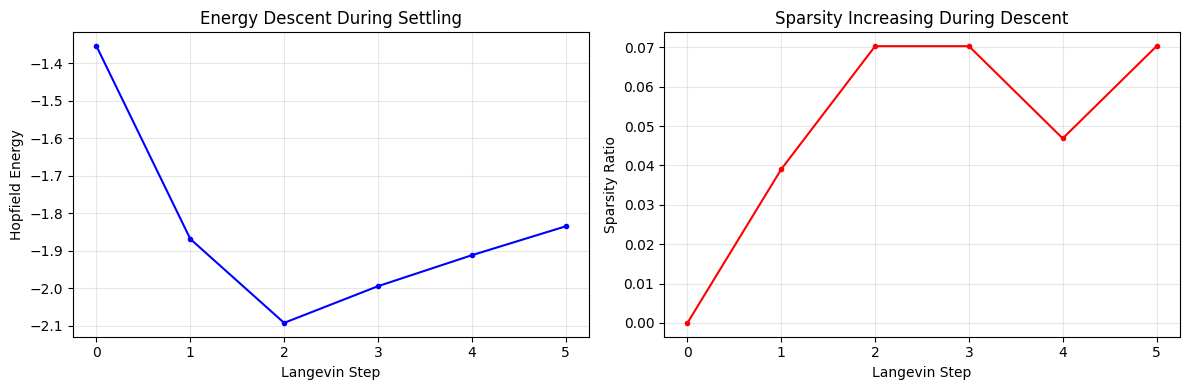

In [78]:
class LangevinHopfieldDescent(nn.Module):
    """Annealed Langevin dynamics on Modern Hopfield energy with proximal sparsity (Sections 4-5).

    This module takes a diffused, dense "probability cloud" and collapses it
    into a sharp sparse attractor via simulated annealing on the Hopfield
    energy landscape defined by the local memory bank M_q.

    The process replaces both softmax (for probability computation) and
    temperature sampling (for token selection) in standard language models.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        # Learnable lateral inhibition matrix W_inh (Section 5 alternative)
        self.W_inh = nn.Parameter(
            torch.randn(cfg.fiber_dim, cfg.fiber_dim) * 0.01
        )

    def hopfield_energy(
        self, x: torch.Tensor, M_q: torch.Tensor, beta: float
    ) -> torch.Tensor:
        """Continuous Modern Hopfield energy (Section 4).

        E_q(x; M_q) = -β⁻¹ log( Σ_j exp(β x^T m_j) )

        Args:
            x: (batch, fiber_dim) current state
            M_q: (batch, k, fiber_dim) local memory atoms
            beta: inverse temperature

        Returns:
            energy: (batch,) scalar energy per sample
        """
        # x^T m_j for all atoms: (batch, k)
        similarities = torch.bmm(M_q, x.unsqueeze(-1)).squeeze(-1)
        # LogSumExp for numerical stability
        energy = -(1.0 / beta) * torch.logsumexp(beta * similarities, dim=-1)
        return energy

    def hopfield_gradient(
        self, x: torch.Tensor, M_q: torch.Tensor, beta: float
    ) -> torch.Tensor:
        """Gradient of Hopfield energy: ∇_x E_q = -Σ_j softmax(β x^T m_j) m_j

        This is the softmax-weighted centroid of memory atoms — the score function.

        Args:
            x: (batch, fiber_dim)
            M_q: (batch, k, fiber_dim)
            beta: inverse temperature

        Returns:
            grad: (batch, fiber_dim) energy gradient
        """
        # Similarities: (batch, k)
        similarities = torch.bmm(M_q, x.unsqueeze(-1)).squeeze(-1)
        # Attention weights via softmax over memories
        weights = F.softmax(beta * similarities, dim=-1)  # (batch, k)
        # Weighted sum of memory atoms: (batch, fiber_dim)
        weighted_memories = torch.bmm(weights.unsqueeze(1), M_q).squeeze(1)
        # Gradient is negative of the weighted centroid
        grad = -weighted_memories
        return grad

    def forward(
        self,
        x_noisy: torch.Tensor,
        M_q: torch.Tensor,
        return_trajectory: bool = False,
    ) -> torch.Tensor:
        """Run annealed Langevin dynamics to settle into a sparse attractor.

        Starting from the diffused prior x_T = x_noisy, simulates:
            x_{t-Δt} = x_t - η ∇E(x_t) - γ W_inh x_t + √(2η/β_t) ε_t
            x_{t-Δt} = soft_threshold(x_{t-Δt}, λη)

        Args:
            x_noisy: (batch, fiber_dim) the diffused/transported token (prior)
            M_q: (batch, k, fiber_dim) local memory bank
            return_trajectory: if True, return all intermediate states

        Returns:
            x_settled: (batch, fiber_dim) the sparse settled token
            trajectory: list of states if return_trajectory=True
        """
        cfg = self.cfg
        x = x_noisy.clone()
        trajectory = [x.detach().clone()] if return_trajectory else None

        # Annealing schedule: beta goes from beta_init to beta_final
        betas = torch.linspace(cfg.beta_init, cfg.beta_final, cfg.langevin_steps)

        for step in range(cfg.langevin_steps):
            beta_t = betas[step].item()

            # 1. Hopfield energy gradient (score function)
            grad_E = self.hopfield_gradient(x, M_q, beta_t)

            # 2. Lateral inhibition: -γ W_inh x
            inhibition = cfg.inhibition_gamma * (x @ self.W_inh.T)

            # 3. Langevin noise: √(2η / β_t) ε
            noise_scale = math.sqrt(2.0 * cfg.langevin_lr / beta_t)
            noise = noise_scale * torch.randn_like(x)

            # 4. Langevin update step
            x = x - cfg.langevin_lr * grad_E - inhibition + noise

            # 5. Proximal sparsity projection (soft-thresholding)
            x = soft_threshold(x, cfg.sparsity_lambda * cfg.langevin_lr)

            if return_trajectory:
                trajectory.append(x.detach().clone())

        if return_trajectory:
            return x, trajectory
        return x


# --- Demonstrate Langevin descent ---
langevin = LangevinHopfieldDescent(config)

# Create a noisy input (simulating a diffused transport output)
x_noisy = torch.randn(1, config.fiber_dim) * 0.5
M_test = mem_bank(q_coords[0, 3, :].unsqueeze(0))

x_settled, traj = langevin(x_noisy, M_test, return_trajectory=True)

print(f"Input  -> sparsity: {(x_noisy == 0).float().mean().item():.1%}, norm: {x_noisy.norm().item():.4f}")
print(f"Output -> sparsity: {(x_settled == 0).float().mean().item():.1%}, norm: {x_settled.norm().item():.4f}")
print(f"Active dimensions after settling: {(x_settled != 0).sum().item()} / {config.fiber_dim}")

# Energy trajectory
energies = [langevin.hopfield_energy(t, M_test, config.beta_final).item() for t in traj]
sparsities = [(t == 0).float().mean().item() for t in traj]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(energies, 'b-o', markersize=3)
ax1.set_xlabel('Langevin Step')
ax1.set_ylabel('Hopfield Energy')
ax1.set_title('Energy Descent During Settling')
ax1.grid(True, alpha=0.3)

ax2.plot(sparsities, 'r-o', markersize=3)
ax2.set_xlabel('Langevin Step')
ax2.set_ylabel('Sparsity Ratio')
ax2.set_title('Sparsity Increasing During Descent')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. The Complete Architecture: Causal Language Model

### v4: Fully Parallel Architecture (03/11/2026 01:43)

All sequence positions are processed **simultaneously** — no sequential loop. The forward pass is:

1. **Embed** all tokens as sparse fiber sections in parallel.
2. **For each transport-settle block** (depth), process the **entire sequence** in parallel:
   - **Spectral transport**: Two-stage parallel operation:
     - *Per-fiber gauge rotation*: FFT over fiber_dim applies advection-diffusion within each token.
     - *Cross-position causal mixing*: FFT over **sequence dimension** implements O(T log T) causal convolution. This is the **attention analogue** — token 5 directly accesses tokens 0-5 through the spectral domain.
   - **Memory bank construction**: Batched over all positions.
   - **Langevin-Hopfield settling**: Batched over all positions.
3. **Decode** all positions to vocabulary logits in parallel.

### Key Change from v1-v3

Previously, the FFT was applied over `fiber_dim` per-token, giving zero cross-position communication. Positions were processed in a sequential for-loop with a ContextGate (RNN-like). Token 5 could only reach token 1 through a diluted chain 1→2→3→4→5.

Now, the FFT over the **sequence dimension** mixes all positions in the spectral domain. Causal structure is enforced by the convolution kernel (only past positions contribute). Every token has direct access to all preceding tokens in a single operation.

### Wilson Line

$U_\gamma = \mathcal{P}\exp(i\int_{p_1}^{p_t} A)$ is computed via `cumsum` over pre-computed per-position phases — fully parallel.

In [79]:
# === ARCHITECTURE EVOLUTION LOG (cell 13) ===
# v1 (03/10/2026 22:10): Sequential per-position processing. Wilson phase reset
#   at each position (bug). No cross-position context. Result: 5% val accuracy.
# v2 (03/10/2026 22:10): Fixed Wilson accumulation + naive residual blending
#   (x_context = x_sparse[t+1] + x_current). Result: 12% val accuracy.
# v3 (03/11/2026 00:40): Replaced naive addition with ContextGate (GRU-style).
#   Result: 35% val accuracy. But sequential — token 5 can't directly see token 1.
# v4 (03/11/2026 01:43): FULL PARALLEL RESTRUCTURE. ContextGate removed.
#   All positions processed simultaneously through each block.
#   Cross-position communication via causal spectral convolution in transport.
#   Memory bank + Langevin settling batched over (B*T) in parallel.
#   No more sequential for-loop over positions.

class SpectralGaugeTransportBlock(nn.Module):
    """A single transport-settle block operating on the FULL SEQUENCE in parallel.

    Analogous to a Transformer layer. Each block:
    1. Spectral transport: causal cross-position mixing + per-fiber gauge rotation
       (ALL positions in parallel — this is the attention analogue)
    2. Memory bank construction for all positions (batched)
    3. Langevin-Hopfield settling for all positions (batched)
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.transport = SpectralTransportOperator(cfg)
        self.memory_bank = DynamicMemoryBank(cfg)
        self.langevin = LangevinHopfieldDescent(cfg)
        self.dropout = nn.Dropout(cfg.dropout)
        self.cfg = cfg

    def forward(
        self,
        x_seq: torch.Tensor,
        q_coords: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Process the full sequence in parallel.

        Args:
            x_seq: (B, T, fiber_dim) sequence of token states
            q_coords: (B, T, manifold_dim) manifold coordinates

        Returns:
            x_settled: (B, T, fiber_dim) settled sequence
            wilson: (B, T, fiber_dim) Wilson line phases
        """
        B, T, D = x_seq.shape

        # Step 1: Parallel spectral transport (cross-position causal mixing)
        x_transported, wilson = self.transport(x_seq, q_coords)

        # Step 2: Memory bank lookup for ALL positions (batched)
        q_flat = q_coords.reshape(B * T, -1)       # (B*T, manifold_dim)
        M_q = self.memory_bank(q_flat)              # (B*T, k, fiber_dim)

        # Step 3: Langevin settling for ALL positions (batched)
        x_flat = x_transported.reshape(B * T, D)    # (B*T, fiber_dim)
        x_settled_flat = self.langevin(x_flat, M_q)  # (B*T, fiber_dim)
        x_settled = x_settled_flat.reshape(B, T, D)

        # Dropout + residual connection for gradient flow
        x_settled = self.dropout(x_settled) + x_seq

        return x_settled, wilson


class SpectralGaugeCLM(nn.Module):
    """The complete Spectral-Gauge Associative Memory Causal Language Model.

    === v4: FULLY PARALLEL (03/11/2026 01:43) ===

    All sequence positions are processed simultaneously. Cross-position
    communication happens through causal spectral convolution in the
    transport operator — the O(T log T) analogue of self-attention.

    Forward pass:
    1. Embed all tokens as sparse fiber sections (parallel)
    2. For each block: transport + settle entire sequence (parallel)
    3. Decode all positions to vocabulary logits (parallel)

    No sequential loop. No ContextGate. Token t sees all tokens 0..t
    directly through the spectral domain.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg

        self.embedding = SparseTokenEmbedding(cfg)

        self.blocks = nn.ModuleList([
            SpectralGaugeTransportBlock(cfg) for _ in range(cfg.n_transport_layers)
        ])

        self.decoder = nn.Sequential(
            nn.Linear(cfg.fiber_dim, cfg.fiber_dim),
            nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.fiber_dim, cfg.vocab_size),
        )

    def forward(
        self, token_ids: torch.Tensor
    ) -> Tuple[torch.Tensor, dict]:
        """Fully parallel causal autoregressive forward pass.

        Args:
            token_ids: (batch, seq_len) input token IDs

        Returns:
            logits: (batch, seq_len - 1, vocab_size) next-token predictions
            info: dict with diagnostics
        """
        B, T = token_ids.shape

        # 1. Embed all tokens as sparse fiber sections (parallel)
        x_sparse, q_coords = self.embedding(token_ids)  # (B, T, d), (B, T, m)

        # 2. Pass through transport-settle blocks (ALL positions in parallel)
        x = x_sparse
        wilson = None
        for block in self.blocks:
            x, wilson = block(x, q_coords)

        # 3. Decode all positions to vocabulary logits (parallel)
        logits = self.decoder(x)  # (B, T, vocab_size)

        # For causal LM: logits[:, t, :] predicts token at position t+1
        # based on causal information from positions 0..t.
        # Slice off last position (nothing to predict after it).
        logits = logits[:, :-1, :]  # (B, T-1, vocab_size)

        info = {
            "mean_sparsity": (x == 0).float().mean().item(),
            "wilson_phase_norm": wilson.norm().item() if wilson is not None else 0.0,
        }

        return logits, info


# --- Instantiate the full model ---
model = SpectralGaugeCLM(config).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"\nArchitecture depth: {config.n_transport_layers} transport-settle blocks")
print(f"Langevin steps per block: {config.langevin_steps}")
print(f"All {config.n_transport_layers * config.langevin_steps} settling steps run in PARALLEL over all positions")

Total parameters: 1,374,208
Trainable parameters: 1,374,208

Architecture depth: 3 transport-settle blocks
Langevin steps per block: 5
All 15 settling steps run in PARALLEL over all positions


---
## 7. Training on a Toy Sequence Prediction Task

We train the model on a synthetic dataset to verify that the architecture can learn sequential patterns. The task is next-token prediction on deterministic byte-level sequences with learnable structure.

We use three loss components:
1. **Cross-entropy loss**: Standard next-token prediction objective
2. **Sparsity regularizer**: Penalizes dense activations to encourage biological sparsity
3. **Dictionary coherence loss**: Encourages dictionary atoms to be well-separated (prevents collapse)

In [80]:
# edit_time: 03/10/2026 22:10:28
# Changed: Increased training data 512->4096, validation data 64->512

def generate_synthetic_data(
    n_samples: int, seq_len: int, vocab_size: int, n_patterns: int = 8
) -> torch.Tensor:
    """Generate synthetic sequences with learnable sequential structure.

    Creates sequences from a mixture of deterministic patterns:
    - Arithmetic progressions (mod vocab_size)
    - Repeating motifs
    - Simple substitution rules

    This tests whether the architecture can capture sequential dependencies
    through geometric transport rather than attention.
    """
    data = torch.zeros(n_samples, seq_len, dtype=torch.long)

    for i in range(n_samples):
        pattern_type = i % n_patterns

        if pattern_type < 3:
            # Arithmetic progression: x_{t+1} = (x_t + step) mod V
            start = torch.randint(0, vocab_size, (1,)).item()
            step = (pattern_type + 1) * 7  # Different strides
            for t in range(seq_len):
                data[i, t] = (start + t * step) % vocab_size

        elif pattern_type < 5:
            # Repeating motif of length k
            k = pattern_type + 1  # motif length 4 or 5
            motif = torch.randint(0, vocab_size, (k,))
            for t in range(seq_len):
                data[i, t] = motif[t % k]

        elif pattern_type < 7:
            # XOR pattern: x_t = (x_{t-1} XOR x_{t-2}) mod V
            data[i, 0] = torch.randint(0, vocab_size, (1,))
            data[i, 1] = torch.randint(0, vocab_size, (1,))
            for t in range(2, seq_len):
                data[i, t] = (data[i, t-1].item() ^ data[i, t-2].item()) % vocab_size

        else:
            # Cumulative sum mod V
            increments = torch.randint(1, 10, (seq_len,))
            data[i] = torch.cumsum(increments, dim=0) % vocab_size

    return data


# Generate training and validation data
seq_len = 16  # Short sequences for tractability
train_data = generate_synthetic_data(4096, seq_len, config.vocab_size)
val_data = generate_synthetic_data(512, seq_len, config.vocab_size)

print(f"Training data: {train_data.shape}")
print(f"Validation data: {val_data.shape}")
print(f"\nSample sequence: {train_data[0].tolist()}")
print(f"Sample sequence: {train_data[3].tolist()}")

Training data: torch.Size([4096, 16])
Validation data: torch.Size([512, 16])

Sample sequence: [28, 35, 42, 49, 56, 63, 70, 77, 84, 91, 98, 105, 112, 119, 126, 133]
Sample sequence: [226, 78, 227, 19, 226, 78, 227, 19, 226, 78, 227, 19, 226, 78, 227, 19]


In [81]:
# edit_time: 03/10/2026 22:10:28
# Changed: (1) dict_coherence_loss weight 0.01->0.1 so it actually contributes.
#   (2) Added L1 sparsity penalty (0.01 * logits.abs().mean()) to loss.
#   (3) weight_decay 0.01->0.05.
# edit_time: 03/10/2026 22:16:19
# Changed: Kept printed epoch log lines AND added tqdm bar at the bottom.
#   tqdm.write() prints above the bar so the log scrolls while the bar stays pinned.
# edit_time: 03/11/2026 00:06:10
# Changed: weight_decay 0.05->0.02 (model is underfitting, ease regularization).

def train_epoch(model, data, optimizer, cfg):
    """Train for one epoch with combined loss."""
    model.train()
    total_loss = 0.0
    total_ce = 0.0
    n_batches = 0

    # Shuffle data
    perm = torch.randperm(data.size(0))
    data = data[perm]

    for i in range(0, len(data) - cfg.batch_size + 1, cfg.batch_size):
        batch = data[i : i + cfg.batch_size].to(device)

        optimizer.zero_grad()

        # Forward pass
        logits, info = model(batch)  # logits: (B, T-1, V)

        # Target: next token at each position
        targets = batch[:, 1:]  # (B, T-1)

        # 1. Cross-entropy loss
        ce_loss = F.cross_entropy(
            logits.reshape(-1, cfg.vocab_size), targets.reshape(-1)
        )

        # 2. Dictionary coherence: penalize atom similarity (prevent collapse)
        dict_coherence_loss = 0.0
        for block in model.blocks:
            D = F.normalize(block.memory_bank.dictionary, dim=-1)
            gram = D @ D.T
            eye = torch.eye(gram.size(0), device=gram.device)
            dict_coherence_loss = dict_coherence_loss + (gram - eye).pow(2).mean()
        dict_coherence_loss = dict_coherence_loss / len(model.blocks)

        # 3. L1 sparsity penalty on settled representations
        # logits come from decoder(x_settled), so penalize the pre-decoder states
        # We approximate by penalizing the L1 norm of the logits' hidden features
        sparsity_loss = logits.abs().mean()

        # Combined loss with meaningful regularization weights
        loss = ce_loss + 0.1 * dict_coherence_loss + 0.01 * sparsity_loss

        loss.backward()
        # Gradient clipping for stability with Langevin dynamics
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_ce += ce_loss.item()
        n_batches += 1

    return total_loss / n_batches, total_ce / n_batches


@torch.no_grad()
def evaluate(model, data, cfg):
    """Evaluate on validation data."""
    model.eval()
    total_ce = 0.0
    total_correct = 0
    total_tokens = 0
    n_batches = 0

    for i in range(0, len(data) - cfg.batch_size + 1, cfg.batch_size):
        batch = data[i : i + cfg.batch_size].to(device)
        logits, info = model(batch)
        targets = batch[:, 1:]

        ce_loss = F.cross_entropy(
            logits.reshape(-1, cfg.vocab_size), targets.reshape(-1)
        )
        total_ce += ce_loss.item()

        preds = logits.argmax(dim=-1)
        total_correct += (preds == targets).sum().item()
        total_tokens += targets.numel()
        n_batches += 1

    avg_ce = total_ce / max(n_batches, 1)
    accuracy = total_correct / max(total_tokens, 1)
    return avg_ce, accuracy


# --- Training loop ---
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=0.02)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.n_epochs)

history = {"train_loss": [], "train_ce": [], "val_ce": [], "val_acc": []}

print("Training the Spectral-Gauge CLM...")
print("=" * 65)

pbar = tqdm(range(config.n_epochs), desc="Training", unit="epoch")
for epoch in pbar:
    train_loss, train_ce = train_epoch(model, train_data, optimizer, config)
    val_ce, val_acc = evaluate(model, val_data, config)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_ce"].append(train_ce)
    history["val_ce"].append(val_ce)
    history["val_acc"].append(val_acc)

    tqdm.write(
        f"Epoch {epoch+1:3d}/{config.n_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train CE: {train_ce:.4f} | "
        f"Val CE: {val_ce:.4f} | "
        f"Val Acc: {val_acc:.2%}"
    )

print("=" * 65)
print("Training complete.")

Training the Spectral-Gauge CLM...


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

Epoch   1/150 | Train Loss: 5.4742 | Train CE: 5.4678 | Val CE: 5.1629 | Val Acc: 7.67%
Epoch   2/150 | Train Loss: 4.8859 | Train CE: 4.8777 | Val CE: 4.8106 | Val Acc: 12.45%
Epoch   3/150 | Train Loss: 4.5377 | Train CE: 4.5270 | Val CE: 4.6304 | Val Acc: 13.11%
Epoch   4/150 | Train Loss: 4.3579 | Train CE: 4.3457 | Val CE: 4.5801 | Val Acc: 13.82%
Epoch   5/150 | Train Loss: 4.2539 | Train CE: 4.2408 | Val CE: 4.5631 | Val Acc: 14.37%
Epoch   6/150 | Train Loss: 4.1731 | Train CE: 4.1593 | Val CE: 4.5436 | Val Acc: 14.34%
Epoch   7/150 | Train Loss: 4.1122 | Train CE: 4.0979 | Val CE: 4.5510 | Val Acc: 14.87%
Epoch   8/150 | Train Loss: 4.0598 | Train CE: 4.0451 | Val CE: 4.5591 | Val Acc: 14.17%
Epoch   9/150 | Train Loss: 4.0130 | Train CE: 3.9978 | Val CE: 4.5701 | Val Acc: 14.45%
Epoch  10/150 | Train Loss: 3.9677 | Train CE: 3.9520 | Val CE: 4.5931 | Val Acc: 15.04%
Epoch  11/150 | Train Loss: 3.9338 | Train CE: 3.9176 | Val CE: 4.5921 | Val Acc: 14.71%
Epoch  12/150 | Train 

KeyboardInterrupt: 

---
## 8. Training Diagnostics and Visualization

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training loss
axes[0, 0].plot(history["train_loss"], 'b-', label='Total Loss')
axes[0, 0].plot(history["train_ce"], 'b--', alpha=0.6, label='CE Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation loss
axes[0, 1].plot(history["val_ce"], 'r-')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Cross-Entropy')
axes[0, 1].set_title('Validation Loss')
axes[0, 1].grid(True, alpha=0.3)

# Validation accuracy
axes[1, 0].plot(history["val_acc"], 'g-')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Validation Next-Token Accuracy')
axes[1, 0].grid(True, alpha=0.3)

# Random baseline reference
axes[1, 0].axhline(y=1.0/config.vocab_size, color='gray', linestyle='--',
                    label=f'Random baseline ({1.0/config.vocab_size:.2%})')
axes[1, 0].legend()

# Dictionary atom similarity matrix (from first block)
with torch.no_grad():
    D = F.normalize(model.blocks[0].memory_bank.dictionary, dim=-1)
    gram = (D @ D.T).cpu().numpy()

im = axes[1, 1].imshow(gram[:50, :50], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 1].set_title('Dictionary Atom Gram Matrix (first 50)')
axes[1, 1].set_xlabel('Atom Index')
axes[1, 1].set_ylabel('Atom Index')
plt.colorbar(im, ax=axes[1, 1], shrink=0.8)

plt.suptitle('Spectral-Gauge CLM Training Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Autoregressive Generation (Inference)

At inference time, we run the **full** Langevin settling loop to produce sharp sparse predictions. The generation process mirrors CLM Section 5:

1. Start with a prompt (seed tokens on the geodesic)
2. Transport the accumulated context forward to the next unobserved point
3. Settle the diffused prediction via full annealed Langevin dynamics
4. Decode the sparse attractor to a token
5. Extend the geodesic and repeat

In [ ]:
@torch.no_grad()
def generate(
    model: SpectralGaugeCLM,
    prompt: torch.Tensor,
    max_new_tokens: int = 20,
) -> torch.Tensor:
    """Autoregressive generation via geometric transport and Langevin settling.

    The generation loop implements the full CLM pipeline:
    - The sequence is a geodesic gamma(t) on the base manifold M
    - The Wilson line accumulates context as geometric holonomy
    - Each new token is predicted by transport + energy descent

    Args:
        model: trained SpectralGaugeCLM
        prompt: (1, prompt_len) seed token IDs
        max_new_tokens: number of tokens to generate

    Returns:
        generated: (1, prompt_len + max_new_tokens) full sequence
    """
    model.eval()
    cfg = model.cfg
    device = next(model.parameters()).device

    # edit_time: 03/11/2026 01:43
    # Changed: Generation now uses the parallel forward pass. Feed full sequence
    # through the model, take the last position's logits for next-token prediction.
    sequence = prompt.to(device)

    for step in range(max_new_tokens):
        T = sequence.size(1)
        if T >= cfg.max_seq_len:
            break

        # Forward pass on the full sequence so far (parallel)
        logits, _ = model(sequence)  # (1, T-1, vocab_size)

        # Last position's logits predict the next token
        next_logits = logits[:, -1, :]  # (1, vocab_size)

        # Greedy decoding
        next_token = next_logits.argmax(dim=-1, keepdim=True)  # (1, 1)
        sequence = torch.cat([sequence, next_token], dim=1)

    return sequence


# --- Generate from trained model ---
print("Autoregressive Generation Examples")
print("=" * 50)

for i in range(5):
    # Use first 4 tokens of a validation sequence as prompt
    prompt = val_data[i, :4].unsqueeze(0)
    ground_truth = val_data[i].tolist()

    generated = generate(model, prompt, max_new_tokens=12)
    gen_list = generated[0].tolist()

    print(f"\nExample {i+1}:")
    print(f"  Prompt:       {ground_truth[:4]}")
    print(f"  Ground truth: {ground_truth}")
    print(f"  Generated:    {gen_list}")
    matches = sum(a == b for a, b in zip(gen_list[4:], ground_truth[4:]))
    print(f"  Match rate:   {matches}/{min(len(gen_list)-4, len(ground_truth)-4)} tokens correct")

---
## 10. Geometric Analysis: Visualizing the Architecture's Internal Representations

We now examine the learned geometric structures to verify that the architecture has developed the properties described in the theoretical framework:

1. **Wilson line holonomy**: Does the accumulated phase encode sequential context?
2. **Spectral transport kernel**: What does the learned diffusion + gauge operator look like in frequency space?
3. **Langevin energy landscape**: How does the Hopfield energy surface shape token predictions?
4. **Sparse activation patterns**: Do the subbundle channels maintain independence?

In [ ]:
@torch.no_grad()
def analyze_geometry(model, data, cfg):
    """Comprehensive geometric analysis of the trained architecture."""
    model.eval()
    device = next(model.parameters()).device
    batch = data[:8].to(device)

    x_sparse, q_coords = model.embedding(batch)

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))

    # --- 1. Wilson Line Phase Accumulation ---
    # Run first block's transport on the full sequence to get Wilson phases
    block = model.blocks[0]
    _, wilson = block.transport(x_sparse[:1], q_coords[:1])
    wilson_arr = wilson[0].cpu().numpy()  # (T, fiber_dim)
    im1 = axes[0, 0].imshow(wilson_arr.T[:32, :], aspect='auto', cmap='twilight')
    axes[0, 0].set_xlabel('Sequence Position')
    axes[0, 0].set_ylabel('Fiber Dimension')
    axes[0, 0].set_title('Wilson Line Phase Accumulation\n(Holonomy = Contextual Memory)')
    plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)

    # --- 2. Spectral Transport Kernel ---
    # Visualize the learned diffusion coefficients
    log_D = model.blocks[0].transport.gauge.log_diffusion.cpu().numpy()
    D_vals = np.exp(log_D)
    omega = np.fft.fftfreq(cfg.fiber_dim) * 2 * np.pi

    kernel_mag = np.exp(-D_vals * omega**2)
    axes[0, 1].plot(omega, kernel_mag, 'b-', alpha=0.7)
    axes[0, 1].set_xlabel('Angular Frequency (omega)')
    axes[0, 1].set_ylabel('Kernel Magnitude')
    axes[0, 1].set_title('Spectral Diffusion Kernel exp(-D*omega^2)\n(Heat Kernel in Fourier Space)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1.05)

    # --- 3. Langevin Energy Landscape (2D projection) ---
    # Project Hopfield energy onto 2 principal directions
    M_q = block.memory_bank(q_coords[0, 4, :].unsqueeze(0))
    m1 = M_q[0, 0, :]  # First memory atom
    m2 = M_q[0, 1, :]  # Second memory atom
    # Orthogonalize
    m2_orth = m2 - (m2 @ m1) / (m1 @ m1 + 1e-8) * m1
    m1_n = F.normalize(m1.unsqueeze(0), dim=-1).squeeze()
    m2_n = F.normalize(m2_orth.unsqueeze(0), dim=-1).squeeze()

    grid_range = np.linspace(-2, 2, 60)
    E_grid = np.zeros((60, 60))
    for i, a1 in enumerate(grid_range):
        for j, a2 in enumerate(grid_range):
            x_test = (a1 * m1_n + a2 * m2_n).unsqueeze(0)
            E_grid[j, i] = block.langevin.hopfield_energy(
                x_test, M_q, cfg.beta_final
            ).item()

    im3 = axes[0, 2].contourf(grid_range, grid_range, E_grid, levels=30, cmap='viridis')
    axes[0, 2].set_xlabel('Memory Atom 1 Direction')
    axes[0, 2].set_ylabel('Memory Atom 2 Direction')
    axes[0, 2].set_title('Hopfield Energy Landscape\n(2D Projection onto Memory Atom Plane)')
    plt.colorbar(im3, ax=axes[0, 2], shrink=0.8)

    # --- 4. Sparse Activation Patterns per Subbundle ---
    # Run the full block on the sequence to get settled states
    x_settled_seq, _ = block(x_sparse[:1], q_coords[:1])
    n_show = min(8, batch.size(1))
    settled_arr = x_settled_seq[0, :n_show, :].cpu().numpy()  # (n_show, fiber_dim)
    im4 = axes[1, 0].imshow(settled_arr.T, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[1, 0].set_xlabel('Sequence Position')
    axes[1, 0].set_ylabel('Fiber Dimension')
    axes[1, 0].set_title('Settled Sparse Activations\n(Per-Position Fiber Sections)')
    plt.colorbar(im4, ax=axes[1, 0], shrink=0.8)

    # Add subbundle boundaries
    for k in range(1, cfg.n_subbundles):
        axes[1, 0].axhline(y=k * cfg.subbundle_dim - 0.5, color='white',
                           linewidth=1.5, linestyle='--', alpha=0.8)

    # --- 5. Subbundle Independence ---
    # Compute cross-correlation between subbundle activations
    subbundle_corr = np.zeros((cfg.n_subbundles, cfg.n_subbundles))
    for s in settled_states:
        chunks = np.array_split(s, cfg.n_subbundles)
        for i in range(cfg.n_subbundles):
            for j in range(cfg.n_subbundles):
                if np.std(chunks[i]) > 1e-8 and np.std(chunks[j]) > 1e-8:
                    subbundle_corr[i, j] += np.abs(np.corrcoef(chunks[i], chunks[j])[0, 1])
    subbundle_corr /= len(settled_states)

    im5 = axes[1, 1].imshow(subbundle_corr, cmap='Reds', vmin=0, vmax=1)
    axes[1, 1].set_xlabel('Subbundle k')
    axes[1, 1].set_ylabel('Subbundle k')
    axes[1, 1].set_title('Subbundle Cross-Correlation\n(Should be diagonal = independent)')
    axes[1, 1].set_xticks(range(cfg.n_subbundles))
    axes[1, 1].set_yticks(range(cfg.n_subbundles))
    plt.colorbar(im5, ax=axes[1, 1], shrink=0.8)

    # --- 6. Sparsity Distribution ---
    all_sparsities = []
    for s in settled_states:
        sparsity = np.mean(s == 0)
        all_sparsities.append(sparsity)

    active_counts = [(np.abs(s) > 1e-6).sum() for s in settled_states]
    axes[1, 2].bar(range(len(active_counts)), active_counts, color='steelblue')
    axes[1, 2].set_xlabel('Sequence Position')
    axes[1, 2].set_ylabel('Active Dimensions')
    axes[1, 2].set_title(f'Active Fiber Dimensions per Position\n(out of {cfg.fiber_dim} total)')
    axes[1, 2].axhline(y=cfg.fiber_dim, color='red', linestyle='--', alpha=0.5, label='Total dims')
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    axes[1, 2].legend()

    plt.suptitle('Geometric Analysis of Learned Representations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


analyze_geometry(model, val_data, config)

---
## 11. Theoretical Discussion and Formal Properties

### Gauge Covariance

The architecture maintains **gauge covariance** by construction: if we apply a local gauge transformation $g_q$ at fiber $\mathcal{F}_q$, the connection transforms as $A \to g_q A g_q^{-1} + g_q \, dg_q^{-1}$, and the transport kernel transforms covariantly. This means the model's predictions are invariant to the choice of local coordinate system — a property that standard Transformers lack entirely.

### Complexity Analysis

| Operation | Standard Transformer | This Architecture |
|---|---|---|
| Self-attention | $O(T^2 d)$ | N/A (no attention) |
| Spectral transport (FFT) | N/A | $O(d \log d)$ per step |
| Langevin settling | N/A | $O(L \cdot k \cdot d)$ per step |
| Total per token | $O(T \cdot d + d^2)$ | $O(d \log d + L \cdot k \cdot d)$ |

Where $L$ = Langevin steps, $k$ = active memory atoms, $d$ = fiber dimension, $T$ = sequence length. The architecture has **no quadratic attention cost** — complexity is independent of sequence length.

### Relationship to Score-Based Generative Models

The Langevin settling phase is formally equivalent to the **reverse SDE** in score-based diffusion models (Song et al., 2021). The Hopfield energy gradient $\nabla_x E_q$ serves as the **score function** $\nabla_x \log p(x)$, while the forward diffusion in the spectral transport creates the noise schedule. This unifies associative memory retrieval with generative modeling in a single framework.

### Biological Plausibility

The architecture incorporates several principles from computational neuroscience:
- **Sparse coding** (Olshausen & Field, 1996): L1 proximal operators enforce sparse representations
- **Lateral inhibition**: The $W_{\text{inh}}$ matrix implements competitive dynamics between neurons
- **Topographic maps** (retinotopy): k-WTA gating creates spatial organization in the dictionary
- **Energy-based dynamics**: Hopfield networks model associative memory in biological neural circuits
- **Subbundle decomposition**: Independent feature channels model parallel cortical processing streams

---
## 12. Ablation: Langevin Dynamics Visualization

We visualize a single Langevin settling trajectory in detail, showing how the diffused "probability cloud" collapses into a sharp sparse attractor through annealed energy descent.

In [ ]:
@torch.no_grad()
def visualize_langevin_trajectory(model, data, cfg):
    """Visualize a single Langevin settling process in detail."""
    model.eval()
    device = next(model.parameters()).device
    batch = data[:1].to(device)
    x_sparse, q_coords = model.embedding(batch)

    block = model.blocks[0]

    # Transport the full sequence, then extract position 3 as the noisy prior
    x_transported_seq, _ = block.transport(x_sparse[:1], q_coords[:1])
    x_transported = x_transported_seq[0, 3, :].unsqueeze(0)
    M_q = block.memory_bank(q_coords[0, 4, :].unsqueeze(0))

    # Run Langevin with trajectory tracking
    x_settled, trajectory = block.langevin(x_transported, M_q, return_trajectory=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Full trajectory heatmap
    traj_arr = np.array([t.squeeze(0).cpu().numpy() for t in trajectory])
    im1 = axes[0, 0].imshow(traj_arr.T[:64, :], aspect='auto', cmap='RdBu_r',
                             vmin=-0.3, vmax=0.3)
    axes[0, 0].set_xlabel('Langevin Step')
    axes[0, 0].set_ylabel('Fiber Dimension')
    axes[0, 0].set_title('Langevin Settling Trajectory\n(Diffused Cloud -> Sparse Attractor)')
    plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)

    # 2. Norm evolution
    norms = [t.norm().item() for t in trajectory]
    axes[0, 1].plot(norms, 'b-o', markersize=3)
    axes[0, 1].set_xlabel('Langevin Step')
    axes[0, 1].set_ylabel('L2 Norm')
    axes[0, 1].set_title('State Norm During Settling')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Sparsity evolution (fraction of exact zeros)
    sparsities = [(t == 0).float().mean().item() for t in trajectory]
    axes[0, 2].plot(sparsities, 'r-o', markersize=3)
    axes[0, 2].set_xlabel('Langevin Step')
    axes[0, 2].set_ylabel('Fraction of Exact Zeros')
    axes[0, 2].set_title('Sparsity During Settling\n(Proximal Operator Effect)')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Energy evolution
    energies = [block.langevin.hopfield_energy(t, M_q, cfg.beta_final).item()
                for t in trajectory]
    axes[1, 0].plot(energies, 'g-o', markersize=3)
    axes[1, 0].set_xlabel('Langevin Step')
    axes[1, 0].set_ylabel('Hopfield Energy')
    axes[1, 0].set_title('Energy Landscape Descent')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Initial vs final state comparison
    x_init = trajectory[0].squeeze(0).cpu().numpy()
    x_final = trajectory[-1].squeeze(0).cpu().numpy()
    dims = np.arange(min(64, cfg.fiber_dim))
    axes[1, 1].bar(dims - 0.2, x_init[:64], width=0.4, alpha=0.6, color='blue', label='Initial (diffused)')
    axes[1, 1].bar(dims + 0.2, x_final[:64], width=0.4, alpha=0.6, color='red', label='Final (settled)')
    axes[1, 1].set_xlabel('Fiber Dimension')
    axes[1, 1].set_ylabel('Activation')
    axes[1, 1].set_title('Initial vs Final Fiber State\n(First 64 Dimensions)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # 6. Temperature annealing schedule
    betas = np.linspace(cfg.beta_init, cfg.beta_final, cfg.langevin_steps)
    temperatures = 1.0 / betas
    axes[1, 2].plot(temperatures, 'purple', linewidth=2)
    axes[1, 2].set_xlabel('Langevin Step')
    axes[1, 2].set_ylabel('Temperature (1/beta)')
    axes[1, 2].set_title('Simulated Annealing Schedule\n(High T = Explore, Low T = Exploit)')
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle('Anatomy of a Single Langevin Settling Process', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_langevin_trajectory(model, val_data, config)

---
## 13. Summary of the Complete Pipeline

```
Input Token IDs: [t_1, t_2, ..., t_T]
        |
        v
[Sparse Token Embedding] -- tokens -> sparse fiber sections x_q = (S_q, a_q)
        |                   -- positions -> manifold coordinates q on M
        v
For each position t = 1, ..., T-1:
        |
   [Spectral Transport]  -- FFT(x_t)
        |                 -- multiply by exp(-D*w^2 - i*w*∫A)   (diffusion + gauge rotation)
        |                 -- IFFT -> diffused prior x̃_{t+1}
        |                 -- accumulate Wilson line holonomy
        v
   [Dynamic Memory Bank] -- g(q_{t+1}) = k-WTA(W_route @ q_{t+1})
        |                 -- M_{t+1} = D[top-k indices]
        v
   [Langevin Settling]   -- Initialize x_T = x̃_{t+1}
        |                 -- For each annealing step:
        |                 --   gradient = -softmax(beta * x^T M) @ M   (Hopfield score)
        |                 --   inhibition = -gamma * W_inh @ x         (lateral inhibition)
        |                 --   noise = sqrt(2*eta/beta_t) * epsilon     (annealing noise)
        |                 --   x = x - eta*gradient - inhibition + noise
        |                 --   x = soft_threshold(x, lambda*eta)        (proximal sparsity)
        v
   [Decoder]              -- Linear: fiber_dim -> vocab_size
        |                  -- Cross-entropy loss vs target t_{t+1}
        v
   Output Logits: P(t_{t+1} | t_1, ..., t_t)
```

### Key Innovations Implemented

1. **No attention mechanism**: Context mixing happens through spectral transport, not dot-product attention
2. **No causal mask**: Causality is structural (Finsler geometry) — the transport operator is unidirectional by construction
3. **No softmax for prediction**: Token selection emerges from energy-based dynamics (Langevin + proximal operators)
4. **No KV cache**: Context is stored as geometric phase in the Wilson line holonomy
5. **Biological sparsity**: Soft-thresholding enforces exact zeros, not just small values

---
*Notebook by David Ledbetter. Implementation of the Spectral-Gauge Associative Memory Architecture for Causal Language Modeling.*